# HDR figures

Four figures, one cell each, written to `figures/hdr/`:

1. **theory** — $f\sigma_8(z)$ for the models whose expansion history matches
   $\Lambda$CDM to better than 1%, so their signal is growth-only and no BAO or
   supernova distance can reach it.
2. **PV data** — the peculiar-velocity compilation, grouped by method family.
3. **RSD data** — the galaxy-clustering compilation, one colour per survey.
4. **forecasts + theory** — ZTF, ZTF+DESI, LSST, DESI and Euclid projected
   precisions against $f(R)$ and nDGP, on a log redshift axis.

Every theory curve is an EFTCAMB run read from `data/theory/eftcamb_*.ecsv`
(`growth-review-eftcamb-export`, or `notebooks/eftcamb_theory.ipynb`); nothing is
recomputed here. The reference in all four panels is the same EFTCAMB $\Lambda$CDM
run, so the figures are mutually consistent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import growth_review as gr
from growth_review import theory as th

gr.use_style()
OUT = Path("../figures/hdr"); OUT.mkdir(parents=True, exist_ok=True)

exports = th.register_exports()
REF = "eftcamb_GR"                     # the Boltzmann LCDM run, reference everywhere
cosmo = th.get(REF)
print(f"{len(exports)} EFTCAMB exports;  reference fsigma8(0) = {cosmo.fsigma8(0.0):.4f}")

14 EFTCAMB exports;  reference fsigma8(0) = 0.4283


## 1. Theory

eftcamb_Kmouflage                max|dH/H| =  0.632 %   dfsigma8(0) = +24.29 %


eftcamb_ScalingCubicGalileon     max|dH/H| =  0.264 %   dfsigma8(0) =  -4.46 %
eftcamb_fR_fR0_1e-04             max|dH/H| =  0.000 %   dfsigma8(0) = +30.06 %
eftcamb_fR_fR0_1e-05             max|dH/H| =  0.000 %   dfsigma8(0) = +15.91 %
eftcamb_fR_fR0_1e-06             max|dH/H| =  0.000 %   dfsigma8(0) =  +5.12 %
eftcamb_nDGP_H0rc1               max|dH/H| =  0.000 %   dfsigma8(0) = +13.49 %
eftcamb_nDGP_H0rc5               max|dH/H| =  0.000 %   dfsigma8(0) =  +3.08 %


written: ../figures/hdr/hdr_theory.pdf


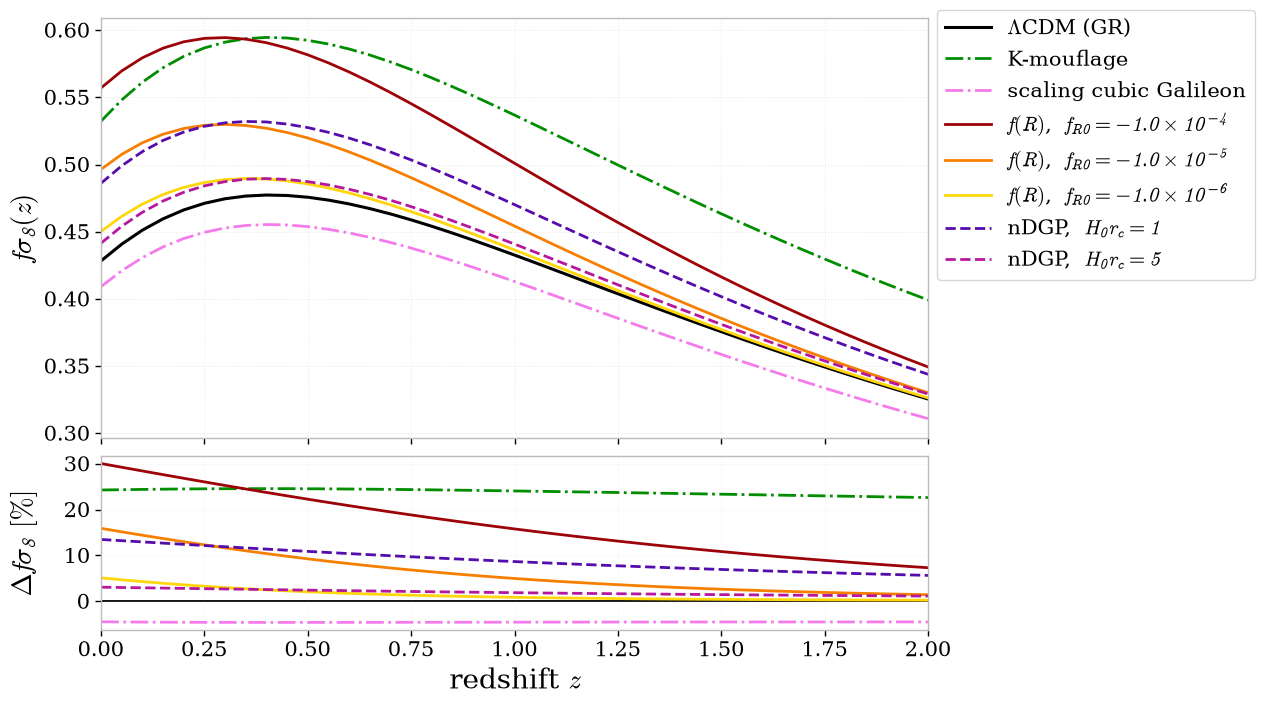

In [2]:
# Background cut: keep models whose H(z) matches LCDM to 1% over 0 < z < 2.
# Horava clears it but its fsigma8 is also LCDM's, so it adds no visible curve.
SELECTION = th.background_unmodified(1e-2, reference=REF, exclude=("Horava",))
dev = th.background_deviations(reference=REF)
for n in SELECTION[1:]:
    print(f"{n:32} max|dH/H| = {100*dev[n]:6.3f} %   "
          f"dfsigma8(0) = {100*(th.get(n).fsigma8(0.)/cosmo.fsigma8(0.)-1):+6.2f} %")

fig, (ax, axr) = plt.subplots(2, 1, figsize=(9.4, 7.2), sharex=True,
                              gridspec_kw=dict(height_ratios=[2.4, 1], hspace=0.06))
z = np.linspace(0, 2, 41)

gr.plotting.plot_theory(ax, SELECTION, z=z)
ax.set_ylabel(r"$f\sigma_8(z)$", fontsize=20)
ax.set_xlim(0, 2)
ax.grid(alpha=0.18, lw=0.7)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.02), handlelength=2.2,
          labelspacing=0.5, borderaxespad=0.0)

gr.plotting.plot_theory_ratio(axr, SELECTION, reference=REF, z=z)
axr.set_ylabel(r"$\Delta f\sigma_8\ [\%]$", fontsize=20)
axr.set_xlabel(r"redshift $z$", fontsize=20)
axr.set_xlim(0, 2)
axr.grid(alpha=0.18, lw=0.7)

fig.align_ylabels()
fig.savefig(OUT / "hdr_theory.pdf", bbox_inches="tight")
print("written:", OUT / "hdr_theory.pdf")

## 2. Peculiar velocities

Grouped by what the estimator does to the velocity field before fitting, not by
survey: the measurements share data (6dFGSv, SDSS PV, SFI++, 2MTF, 2M++ recur
across most of them), so a per-survey legend would suggest an independence that is
not there.

24 measurements;  written: ../figures/hdr/hdr_pv.pdf
  excluded Feix2015: fsigma8 from luminosity-function fluctuations, not from measured velocities
  excluded Feix2017: same, SDSS DR13
  excluded MaBranchiniScott2012: velocity-vs-gravity-field comparison (PSCz), not a direct PV fsigma8
  excluded Nusser2017: quotes an interval on the velocity-density correlation; the midpoint is derived, not a published fsigma8 (provenance='der')
\caption{Measurements of $f\sigma_8$ from peculiar velocities at $z<0.1$, compared with the $\Lambda$CDM prediction for a Planck~2018 fiducial cosmology (black line). The compilation is inhomogeneous --- the measurements share data and differ in normalisation --- so points are grouped by the method used to extract $f\sigma_8$ rather than by survey. The DESI~DR1 consensus (red star) combines the three estimators applied to that survey, accounting for their correlation. Points at nearly coincident redshifts are displaced horizontally for legibility. Error bars

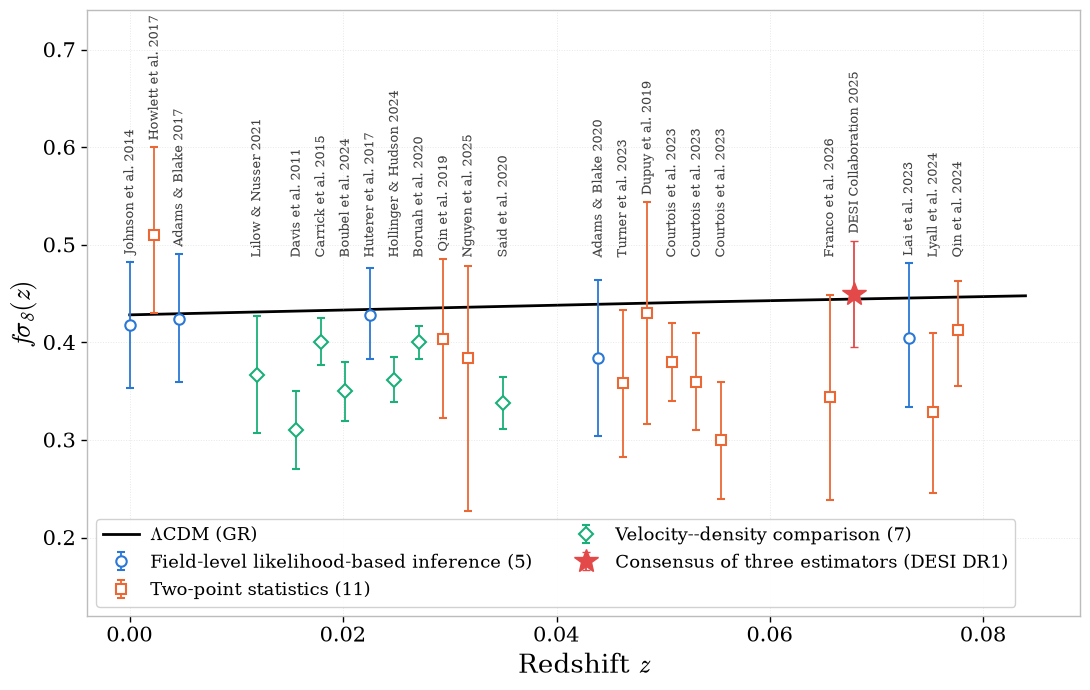

In [3]:
# INDIRECT_PV_KEYS: rows that use PV data but do not measure fsigma8 from the
# velocities themselves -- luminosity-function fluctuations (Feix+15,+17), a
# velocity-vs-gravity-field comparison (Ma, Branchini & Scott 2012), and an
# interval midpoint rather than a published value (Nusser 2017). They stay in the
# compilation; this panel is about direct PV measurements.
from growth_review.figures import INDIRECT_PV_KEYS

fig_pv, meta_pv = gr.figures.fig_pv(cosmo=cosmo, exclude_keys=INDIRECT_PV_KEYS)
fig_pv.savefig(OUT / "hdr_pv.pdf", bbox_inches="tight")
print(f"{meta_pv['n']} measurements;  written: {OUT / 'hdr_pv.pdf'}")
for key, why in meta_pv["excluded"].items():
    print(f"  excluded {key}: {why}")
print(meta_pv["caption"])

## 3. Redshift-space distortions

20 measurements;  written: ../figures/hdr/hdr_rsd.pdf
\caption{Measurements of $f\sigma_8(z)$ from galaxy clustering (redshift-space distortions), compared with the $\Lambda$CDM prediction for a Planck~2018 fiducial cosmology (black line). Points are coloured by survey; DESI~DR1 full-shape results are shown in red and labelled by tracer sample. Of the SDSS-family measurements only the first (SDSS~MGS) and the last (eBOSS~DR16) are shown, so that the gain in precision over two decades stays legible. Points at nearly coincident redshifts are displaced horizontally for legibility.}


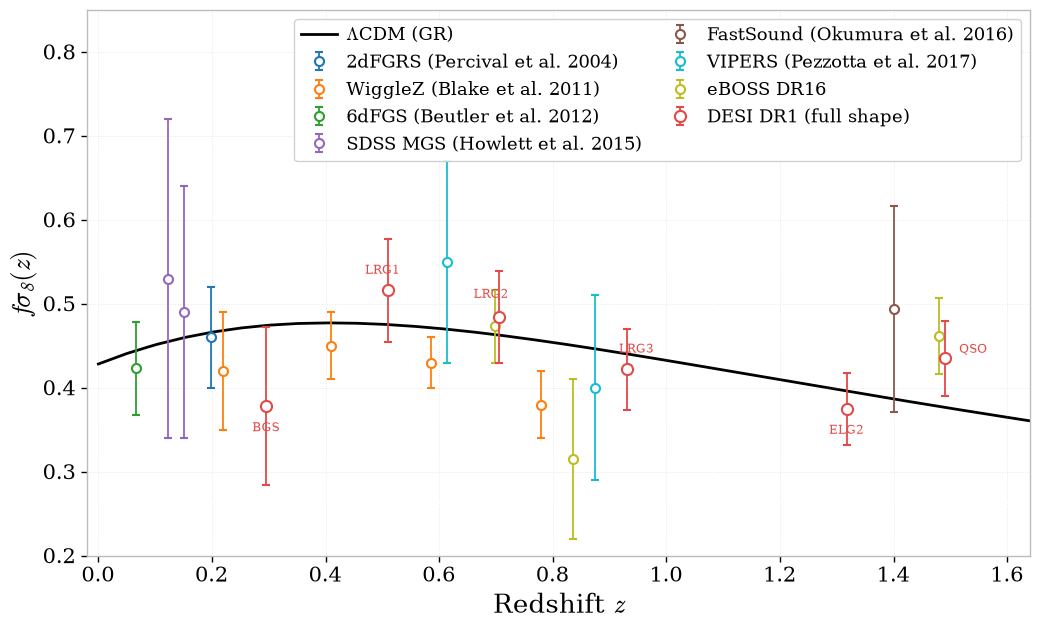

In [4]:
fig_rsd, meta_rsd = gr.figures.fig_rsd(cosmo=cosmo)
fig_rsd.savefig(OUT / "hdr_rsd.pdf", bbox_inches="tight")
print(f"{meta_rsd['n']} measurements;  written: {OUT / 'hdr_rsd.pdf'}")
print(meta_rsd["caption"])

## 4. Forecasts against $f(R)$ and nDGP

Forecast bars carry no central value, so they are drawn around a model curve: the
peculiar-velocity programmes and DESI around $\Lambda$CDM, **Euclid around the
$|f_{R0}|=10^{-5}$ curve** — at $z>0.7$ every model has nearly converged on
$\Lambda$CDM, so putting Euclid's 1-2% bars there instead shows directly whether
that model would be separable. The log redshift axis is what puts the PV
programmes ($z\simeq0.05$) and the spectroscopic ones on the same panel.

written: ../figures/hdr/hdr_forecasts_theory.pdf

programme     $f(R)$,  $f_{  $f(R)$,  $f_{  nDGP,  $H_0r_  nDGP,  $H_0r_
ZTF                    0.8s           0.2s           0.7s           0.2s
ZTF+DESI               1.9s           0.6s           1.6s           0.4s
LSST                   2.0s           0.6s           1.8s           0.4s
DESI                   7.3s           1.5s          11.7s           2.5s
Euclid                15.3s           2.8s          27.7s           6.0s


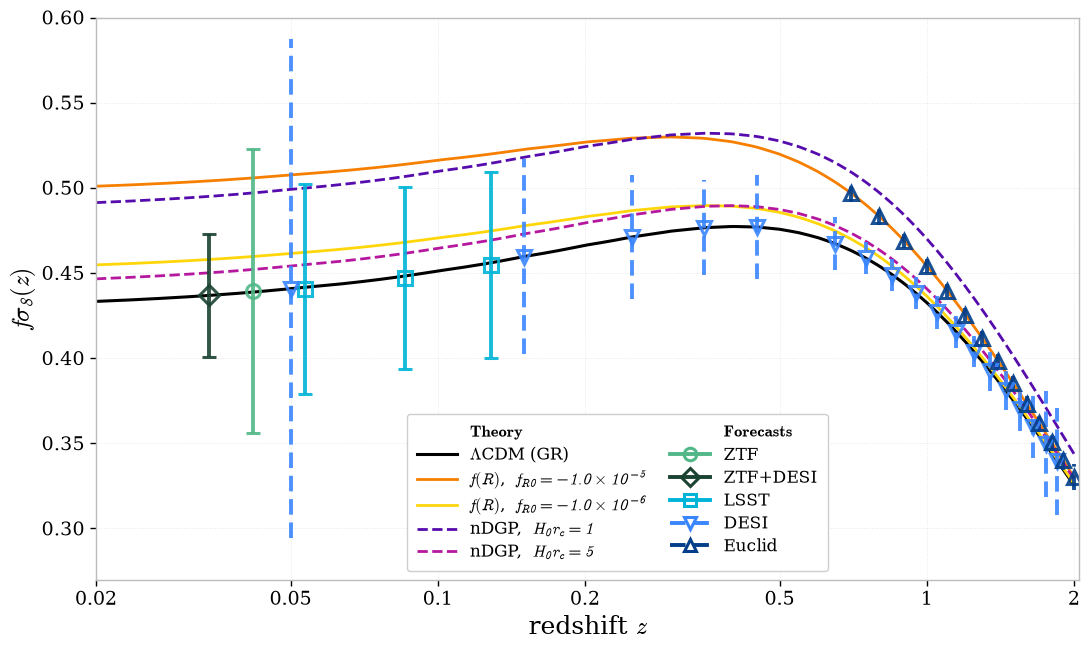

In [5]:
from matplotlib.lines import Line2D

fc = gr.load_fsigma8(kind="forecast")

# LSST's redshift ranges are nested in the source table; only the three disjoint
# bins are kept. `dodge` separates programmes forecasting the same bins -- a shift
# of the plotted abscissa only.
DISJOINT = ("[0.02, 0.06]", "[0.06, 0.10]", "[0.10, 0.14]")


def pv_bins(ref):
    sub = fc[fc["ref"] == ref]
    return sub[sub["label"].apply(lambda s: any(w in s for w in DISJOINT))]


# The two DESI design tables (BGS, and ELG/LRG/QSO) are one programme, so they are
# drawn as one series.
desi = fc[fc["dataset"].isin(["bao_rsd_desi", "bao_rsd_desi_bgs"])].sort_values("z")

# The extreme f(R) tier (|f_R0| = 1e-4) is left out: excluded by current data, and
# it compresses the panel around the models still in play.
MODELS = ["eftcamb_fR_fR0_1e-05", "eftcamb_fR_fR0_1e-06",
          "eftcamb_nDGP_H0rc1", "eftcamb_nDGP_H0rc5"]
EUCLID_ANCHOR = "eftcamb_fR_fR0_1e-05"

# Colours: theory keeps the EFTCAMB palette (black, warm for f(R), purple/magenta
# for nDGP), so the forecasts get cool hues and cannot be mistaken for a model --
# greens for peculiar velocities, blues for redshift-space distortions. This is
# also why DESI is not in the package's reserved red here: red sits next to the
# f(R) curves in hue, which is exactly the confusion to avoid.
#   probe: "pv" -> thick capped solid bars, "rsd" -> thick uncapped dashed bars
SERIES = [
    ("ZTF",      fc[fc["ref"] == "ZTF"],      0.93, REF,           "#52b788", "o", "pv"),
    ("ZTF+DESI", fc[fc["ref"] == "ZTF_DESI"], 1.0,  REF,           "#1b4332", "D", "pv"),
    ("LSST",     pv_bins("LSST_Full"),        1.07, REF,           "#00b4d8", "s", "pv"),
    ("DESI",     desi,                        1.0,  REF,           "#3a86ff", "v", "rsd"),
    ("Euclid",   fc[fc["dataset"] == "fsigma8_euclid"], 1.0, EUCLID_ANCHOR,
     "#023e8a", "^", "rsd"),
]

fig, ax = plt.subplots(figsize=(11, 6.6))
z = np.logspace(np.log10(0.02), np.log10(2.0), 200)

theory_lines = gr.plotting.plot_theory(ax, [REF] + MODELS, z=z, zorder=1)

forecast_handles = []
for label, rows, dodge, anchor, color, marker, probe in SERIES:
    bars = dict(capsize=5, capthick=2.6) if probe == "pv" else dict(capsize=0)
    container = gr.plotting.plot_forecasts(
        ax, rows, th.get(anchor), color=color, marker=marker, ms=10, mew=2.2,
        elinewidth=2.8, x=rows["z"].to_numpy() * dodge, label=label, **bars)
    if probe == "rsd":                       # dashed bars: RSD, not PV
        for barcol in container.lines[2]:
            barcol.set_linestyle((0, (4, 2)))
    forecast_handles.append(Line2D([], [], color=color, marker=marker, ms=9,
                                   mfc="none", mew=2.2, lw=2.8,
                                   ls="-" if probe == "pv" else (0, (4, 2)),
                                   label=label))

ax.set_xscale("log")
ax.set_xlim(0.02, 2.05)
ax.set_ylim(0.27, 0.60)
ax.set_xticks([0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0])
ax.set_xticklabels(["0.02", "0.05", "0.1", "0.2", "0.5", "1", "2"])
ax.minorticks_off()
ax.set_xlabel(r"redshift $z$", fontsize=18)
ax.set_ylabel(r"$f\sigma_8(z)$", fontsize=18)
ax.tick_params(labelsize=14)
ax.grid(alpha=0.18, lw=0.7)
ax.set_axisbelow(True)

# Two columns with their own bold heading: matplotlib fills a multi-column legend
# column-major, so an invisible handle at the head of each block of six becomes
# that column's title.
head = lambda text: Line2D([], [], ls="none", marker="", label=rf"$\bf{{{text}}}$")
handles = ([head("Theory")] + list(theory_lines)
           + [head("Forecasts")] + forecast_handles)
ax.legend(handles=handles, ncol=2, loc="lower center", bbox_to_anchor=(0.53, 0.0),
          fontsize=12, framealpha=0.95, handlelength=2.4, labelspacing=0.35,
          columnspacing=1.4, borderpad=0.6)

fig.tight_layout()
fig.savefig(OUT / "hdr_forecasts_theory.pdf", bbox_inches="tight")
print("written:", OUT / "hdr_forecasts_theory.pdf")

# What each programme could say about these models: |dfsigma8|/sigma_forecast,
# combined in quadrature over its bins (independent bins assumed).
print(f"\n{'programme':12}" + "".join(f"{th.get(n).label[:13]:>15}" for n in MODELS))
for label, rows, _, _, _, _, _ in SERIES:
    zz = rows["z"].to_numpy()
    sig = rows["frac_err"].to_numpy() * cosmo.fsigma8(zz)
    line = f"{label:12}"
    for n in MODELS:
        d = np.abs(th.get(n).fsigma8(zz) - cosmo.fsigma8(zz))
        line += f"{np.sqrt(((d / sig) ** 2).sum()):14.1f}s"
    print(line)

The table is the point of the figure: projected separation from $\Lambda$CDM in
$\sigma$, per programme, assuming independent bins and no shared systematics — an
upper bound, since peculiar-velocity analyses are dominated by distance-indicator
calibration rather than by counting statistics. Euclid's own numbers are
optimistic on top of that: its tabulated precision is fractional on $f$, used here
as fractional on $f\sigma_8$.